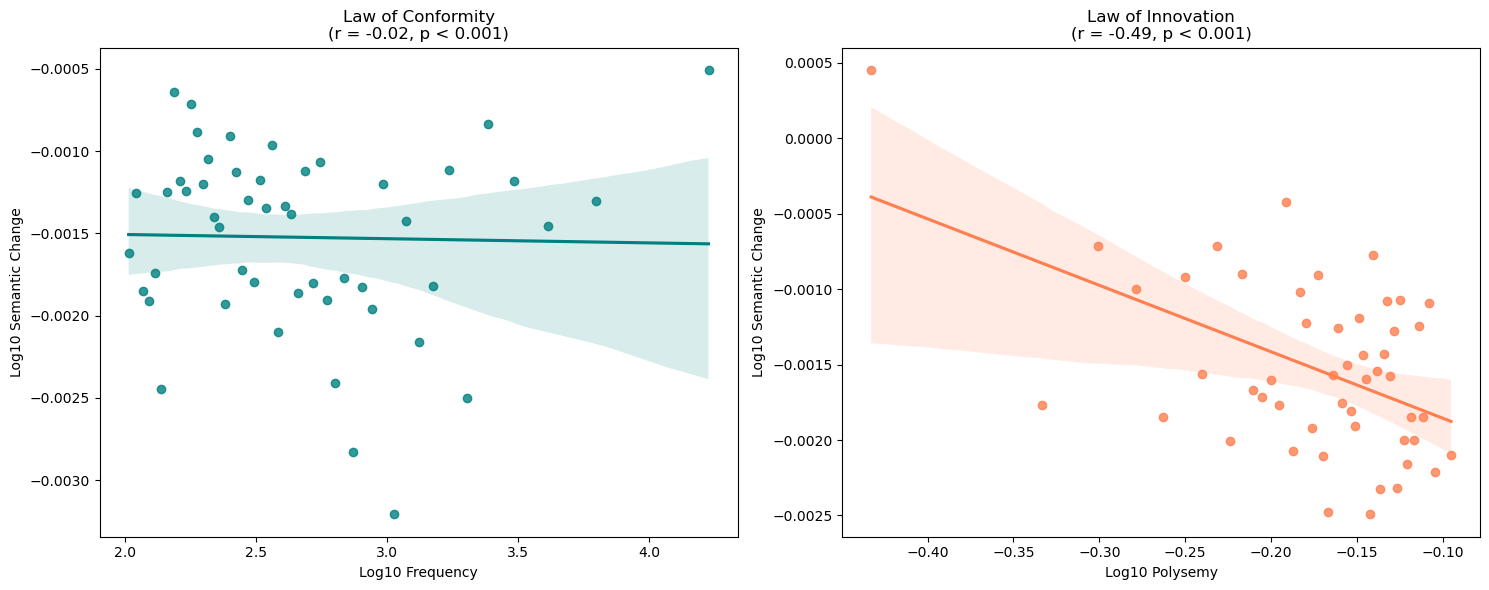


 Summary table
          Law      Predictor  Correlation (r)  Slope (beta)   P-value
0  Conformity  Frequency (f)        -0.022428     -0.000025  0.877136
1  Innovation   Polysemy (d)        -0.493670     -0.004403  0.000269


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress


df = pd.read_csv('../Datasets/final_results_CLEANED.csv')

df['log_freq'] = np.log10(df['frequency'])
df['log_change'] = np.log10(df['semantic_change'])
df['log_poly'] = np.log10(df['polysemy'])

# Law of comformity (freq vs change)
df['freq_bin'] = pd.qcut(df['log_freq'], 50, labels=False, duplicates='drop')
bin_conf = df.groupby('freq_bin').agg({'log_freq': 'mean', 'log_change': 'mean'})
slope_c, intercept_c, r_c, p_c, _ = linregress(bin_conf['log_freq'], bin_conf['log_change'])

# Law of innovation (polysemy vs change)
df['poly_bin'] = pd.qcut(df['log_poly'], 50, labels=False, duplicates='drop')
bin_inn = df.groupby('poly_bin').agg({'log_poly': 'mean', 'log_change': 'mean'})
slope_i, intercept_i, r_i, p_i, _ = linregress(bin_inn['log_poly'], bin_inn['log_change'])

##Viz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Law of Conformity
sns.regplot(x='log_freq', y='log_change', data=bin_conf, ax=ax1, color='teal')
ax1.set_title(f'Law of Conformity\n(r = {r_c:.2f}, p < 0.001)')
ax1.set_xlabel('Log10 Frequency')
ax1.set_ylabel('Log10 Semantic Change')

# Law of Innovation
sns.regplot(x='log_poly', y='log_change', data=bin_inn, ax=ax2, color='coral')
ax2.set_title(f'Law of Innovation\n(r = {r_i:.2f}, p < 0.001)')
ax2.set_xlabel('Log10 Polysemy')
ax2.set_ylabel('Log10 Semantic Change')

plt.tight_layout()
plt.savefig('../Datasets/FINAL_LAWS_PLOT.png')
plt.show()

# Summary table
summary_data = {
    "Law": ["Conformity", "Innovation"],
    "Predictor": ["Frequency (f)", "Polysemy (d)"],
    "Correlation (r)": [r_c, r_i],
    "Slope (beta)": [slope_c, slope_i],
    "P-value": [p_c, p_i]
}
summary_table = pd.DataFrame(summary_data)
print("\n Summary table")
print(summary_table)